In [ ]:
import torch
import torch.nn as nn
from torchvision import transforms
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader
import time
from sklearn.manifold import TSNE

In [ ]:
# how gradients, graph and clone works when calculations are branched

x = torch.tensor(2.0, requires_grad=True)
y = torch.tensor(4)
a = x**2
c = a.clone()
b = c + 2 # different branch
z = torch.sqrt(a)
loss = (z-y)**2

loss.backward()
try:
  b.backward()
except Exception as e:
  print(f"Error: {e} \n The compute graph x->a->z->loss is deleted (not entire graph), so the calculation of derivative of b wrt x is not possible (no more x->a->b track) but there's still track of a->b computation")
b_c = torch.autograd.grad(b,c)[0]
b_a = torch.autograd.grad(b,a)[0]
print(f"Derivative of b wrt c: {b_c}, and memory address: {b_c.data_ptr}")
print(f"Derivative of b wrt a: {b_a}, and memory address: {b_a.data_ptr}")
if b_c.data_ptr != b_a.data_ptr:
  print("Even though the gradients b_c and b_a are the same (because of same values, c cloned from a), both have their independent data and gradients storage. This is where clone is helpful to keep the gradients separate for different branches rather than accumulating into one only.")

Error: Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward. 
 The compute graph x->a->z->loss is deleted (not entire graph), so the calculation of derivative of b wrt x is not possible (no more x->a->b track) but there's still track of a->b computation
Derivative of b wrt c: 1.0, and memory address: <built-in method data_ptr of Tensor object at 0x7e88f7b04410>
Derivative of b wrt a: 1.0, and memory address: <built-in method data_ptr of Tensor object at 0x7e88f7b04460>
Even though the gradients b_c and b_a are the same (because of same values, c cloned from a), both have their independent data and gradients storage. This is where clone is helpful to keep the gradients separate for di

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
def evaluate(loader, model, loss_fn, device, max_batch=5):
  total_loss = 0
  if max_batch <= 0:
    return float("nan")
  elif max_batch is None:
    max_batch = len(loader)
  else:
    max_batch = min(max_batch, len(loader))

  for i, (x, _) in enumerate(loader):
    if i < max_batch:
      with torch.no_grad():
        x = x.to(device)
        reconst, _ = model(x)
        loss = loss_fn(reconst, x)
      total_loss += loss.item()
    else:
      break

  return total_loss/max_batch

In [ ]:
def plot_training_results(train_losses, val_losses, eval_interval, title):
    plt.figure(figsize=(6, 4))

    # Map to real global steps
    steps = (np.arange(len(train_losses)) + 1) * eval_interval

    plt.plot(steps, train_losses, label='Train Loss', alpha=0.5)
    plt.plot(steps, val_losses, label='Val Loss')

    plt.title(title)
    plt.xlabel('Global Steps')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    plt.tight_layout()
    plt.show()

## Latent Space Dim=2

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

In [ ]:
mnist_train = MNIST(
    root="/content/drive/My Drive/PyTorch Exercise",
    train=True,
    download=True,
    transform=transform
    )

mnist_test = MNIST(
    root="/content/drive/My Drive/PyTorch Exercise",
    train=False,
    download=True,
    transform=transform
    )

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.39MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 130kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.5MB/s]


In [ ]:
print(f"Train dataset size: {len(mnist_train)}")
print(f"Test dataset size: {len(mnist_test)}")
print(f"Image shape: {mnist_train[0][0].shape}")

Train dataset size: 60000
Test dataset size: 10000
Image shape: torch.Size([1, 28, 28])


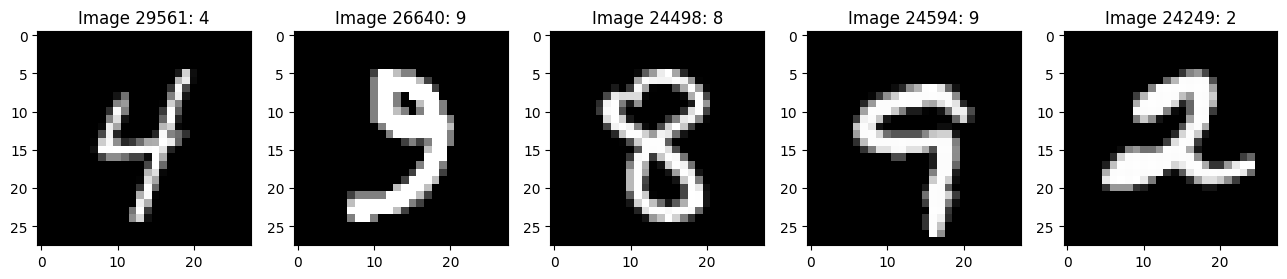

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(123)

random_indices = np.random.choice(len(mnist_train), size=5, replace=False)

fig, axes = plt.subplots(1, 5, figsize=(16, 8))

for ax,i in zip(axes, random_indices):
  ax.imshow(mnist_train[i][0].squeeze(), cmap="gray")
  ax.set_title(f"Image {i}: {mnist_train[i][1]}")

plt.show()

In [ ]:
train_loader = DataLoader(mnist_train, batch_size=32, shuffle=True, num_workers=0)
test_loader = DataLoader(mnist_test, batch_size=32, shuffle=False, num_workers=0)

In [ ]:
class Autoencoder(nn.Module):
  def __init__(self):
    super().__init__()
    self.encoder = nn.Sequential(
        nn.Flatten(),
        nn.Linear(28*28, 128),
        nn.Linear(128, 32),
        nn.Linear(32, 4),
        nn.Linear(4, 2),
    )
    self.decoder = nn.Sequential(
        nn.Linear(2, 4),
        nn.Linear(4, 32),
        nn.Linear(32, 128),
        nn.Linear(128, 28*28),
        # nn.Sigmoid() since the reconstructed image should match the input image distribution
    )

  def forward(self, x):
    x1 = self.encoder(x)
    x2 = self.decoder(x1)
    y = x2.view(x.shape[0], 1, 28, 28)

    return y, x1 # to plot latent representation

In [ ]:
torch.manual_seed(123)
model = Autoencoder()
model.to(device)

loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
epochs = 100
global_step = 0
train_losses, val_losses = [], []

t1 = time.time()

model.train()
for epoch in range(epochs):
  for x, _ in train_loader:
    x = x.to(device)
    optimizer.zero_grad()
    reconst, _ = model(x)
    loss = loss_fn(reconst, x)
    loss.backward()
    optimizer.step()
    global_step += 1

    if global_step % 500 == 0:
      model.eval()
      train_loss = evaluate(train_loader, model, loss_fn, device, max_batch=20)
      val_loss = evaluate(test_loader, model, loss_fn, device, max_batch=20)
      model.train()
      print(f"Epoch: {epoch:3d} \t\t Step: {global_step:5d}")
      print(f"\t\t\tTrain Loss: {train_loss}")
      print(f"\t\t\tValidation Loss: {val_loss}")
      train_losses.append(train_loss)
      val_losses.append(val_loss)

t2 = time.time()

print(f"Total training time: {t2-t1}s")

Epoch:   0 		 Step:   500
			Train Loss: 1.0018359690904617
			Validation Loss: 0.9379834532737732
Epoch:   0 		 Step:  1000
			Train Loss: 0.9838579714298248
			Validation Loss: 0.9311559051275253
Epoch:   0 		 Step:  1500
			Train Loss: 0.9959184736013412
			Validation Loss: 0.924760377407074
Epoch:   1 		 Step:  2000
			Train Loss: 0.9955430716276169
			Validation Loss: 0.9186511814594269
Epoch:   1 		 Step:  2500
			Train Loss: 0.960956871509552
			Validation Loss: 0.9127298623323441
Epoch:   1 		 Step:  3000
			Train Loss: 0.9544656693935394
			Validation Loss: 0.9069199234247207
Epoch:   1 		 Step:  3500
			Train Loss: 0.9880730271339416
			Validation Loss: 0.9011799216270446
Epoch:   2 		 Step:  4000
			Train Loss: 0.9698951214551925
			Validation Loss: 0.8953783512115479
Epoch:   2 		 Step:  4500
			Train Loss: 0.9507989943027496
			Validation Loss: 0.8895229160785675
Epoch:   2 		 Step:  5000
			Train Loss: 0.9567166686058044
			Validation Loss: 0.8835290431976318
Epoch:   2 	

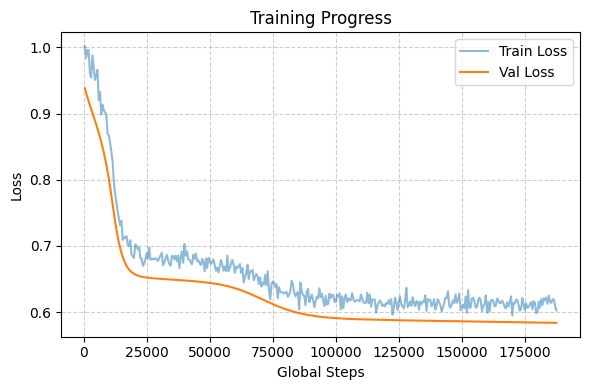

In [ ]:
plot_training_results(train_losses, val_losses, 500, title="Training Progress")

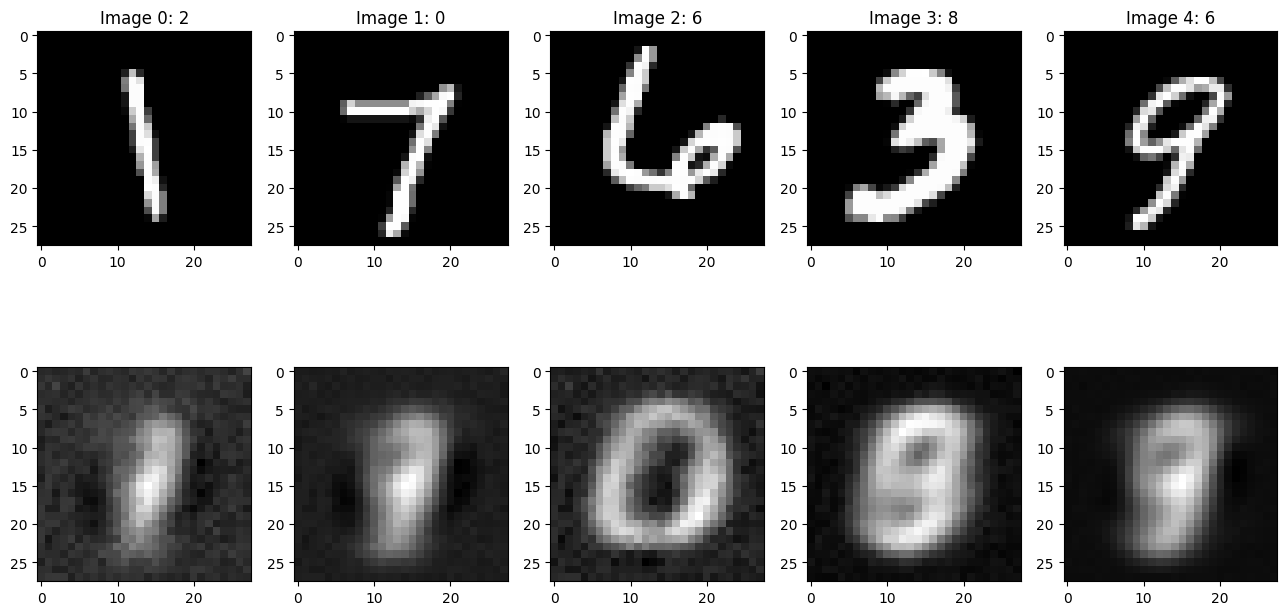

In [ ]:
np.random.seed(123)
random_indices = np.random.choice(len(mnist_test), size=5)

fig, axes = plt.subplots(2, 5, figsize=(16, 8))

model.eval()
for i, ind in enumerate(random_indices):
  with torch.no_grad():
    input = mnist_test[ind][0].to(device)
    reconst, _ = model(input.unsqueeze(0))
  axes[0][i].imshow(input.squeeze().cpu().numpy(), cmap="gray")
  axes[1][i].imshow(reconst.squeeze().cpu().numpy(), cmap="gray")
  axes[0][i].set_title(f"Image {i}: {mnist_train[ind][1]}")

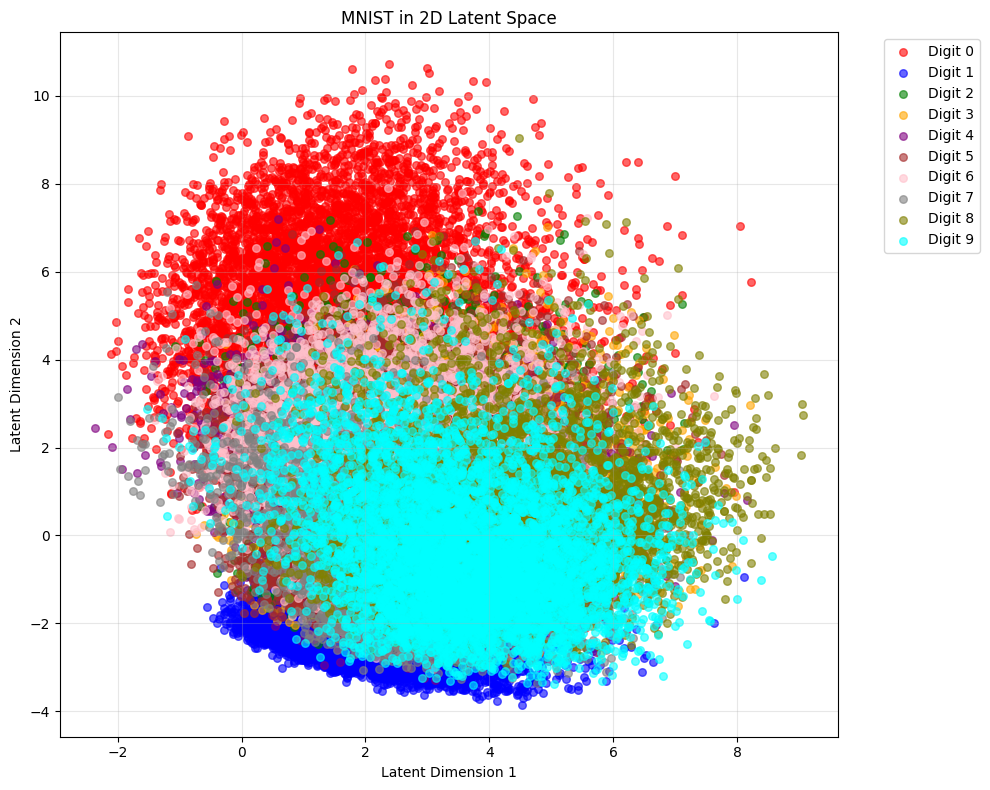

In [ ]:
all_latents = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in train_loader:
        images = images.to(device)
        latents = model.encoder(images)

        all_latents.append(latents.cpu().numpy())
        all_labels.append(labels.numpy())

latents = np.vstack(all_latents)
labels = np.concatenate(all_labels)

# Plot
plt.figure(figsize=(10, 8))

# Define colors for each digit (0-9)
colors = ['red', 'blue', 'green', 'orange', 'purple',
          'brown', 'pink', 'gray', 'olive', 'cyan']

# Plot each digit with its own color
for digit in range(10):
    mask = labels == digit
    plt.scatter(latents[mask, 0], latents[mask, 1],
                c=colors[digit], label=f'Digit {digit}',
                alpha=0.6, s=30)

plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.title('MNIST in 2D Latent Space')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Latent Space Dim = 10

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor()
])

In [ ]:
mnist_train = MNIST(
    root="/content/drive/My Drive/PyTorch Exercise",
    train=True,
    download=True,
    transform=transform
    )

mnist_test = MNIST(
    root="/content/drive/My Drive/PyTorch Exercise",
    train=False,
    download=True,
    transform=transform
    )

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 472kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.41MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.8MB/s]


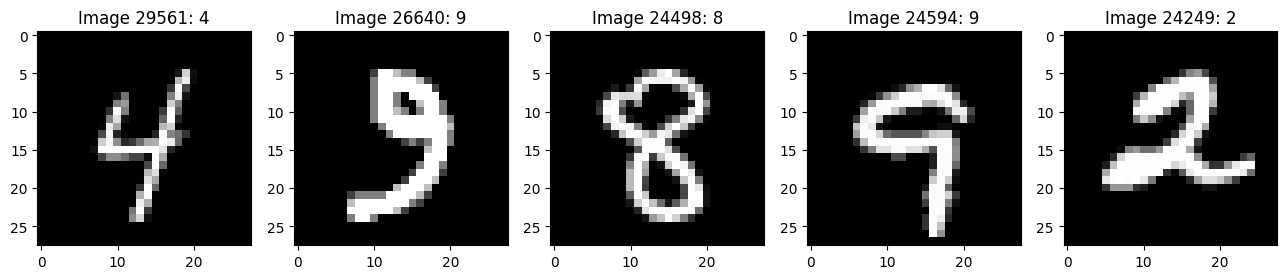

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(123)

random_indices = np.random.choice(len(mnist_train), size=5, replace=False)

fig, axes = plt.subplots(1, 5, figsize=(16, 8))

for ax,i in zip(axes, random_indices):
  ax.imshow(mnist_train[i][0].squeeze(), cmap="gray")
  ax.set_title(f"Image {i}: {mnist_train[i][1]}")

plt.show()

In [ ]:
train_loader = DataLoader(mnist_train, batch_size=32, shuffle=True, num_workers=0)
test_loader = DataLoader(mnist_test, batch_size=32, shuffle=False, num_workers=0)

In [ ]:
class Autoencoder2(nn.Module):
  def __init__(self):
    super().__init__()
    self.encoder = nn.Sequential(
        nn.Flatten(),
        nn.Linear(28*28, 256),
        nn.ReLU(),
        nn.Linear(256, 64),
        nn.ReLU(),
        nn.Linear(64, 10),
    )
    self.decoder = nn.Sequential(
        nn.Linear(10, 64),
        nn.ReLU(),
        nn.Linear(64, 256),
        nn.ReLU(),
        nn.Linear(256, 28*28),
        nn.Sigmoid()
    )

  def forward(self, x):
    x1 = self.encoder(x)
    x2 = self.decoder(x1)
    y = x2.view(x.shape[0], 1, 28, 28)

    return y, x1 # to plot latent representation

In [ ]:
torch.manual_seed(123)
model2 = Autoencoder2()
model2.to(device)

loss_fn = nn.MSELoss()
optimizer2 = torch.optim.Adam(model2.parameters(), lr=0.001)
epochs = 20
global_step2 = 0
train_losses2, val_losses2 = [], []

t3 = time.time()

model2.train()
for epoch in range(epochs):
  for x, _ in train_loader:
    x = x.to(device)
    optimizer2.zero_grad()
    reconst, _ = model2(x)
    loss = loss_fn(reconst, x)
    loss.backward()
    optimizer2.step()
    global_step2 += 1

    if global_step2 % 500 == 0:
      model2.eval()
      train_loss2 = evaluate(train_loader, model2, loss_fn, device, max_batch=20)
      val_loss2 = evaluate(test_loader, model2, loss_fn, device, max_batch=20)
      model2.train()
      print(f"Epoch: {epoch:3d} \t\t Step: {global_step2:5d}")
      print(f"\t\t\tTrain Loss: {train_loss2}")
      print(f"\t\t\tValidation Loss: {val_loss2}")
      train_losses2.append(train_loss2)
      val_losses2.append(val_loss2)

t4 = time.time()

print(f"Total training time: {t4-t3}s")

Epoch:   0 		 Step:   500
			Train Loss: 0.035123050305992366
			Validation Loss: 0.034982237406075
Epoch:   0 		 Step:  1000
			Train Loss: 0.02768312217667699
			Validation Loss: 0.027378127072006465
Epoch:   0 		 Step:  1500
			Train Loss: 0.023628005385398866
			Validation Loss: 0.023594328109174965
Epoch:   1 		 Step:  2000
			Train Loss: 0.02120891734957695
			Validation Loss: 0.02171483701094985
Epoch:   1 		 Step:  2500
			Train Loss: 0.020701633021235465
			Validation Loss: 0.0208218558691442
Epoch:   1 		 Step:  3000
			Train Loss: 0.019851771462708712
			Validation Loss: 0.0198570697568357
Epoch:   1 		 Step:  3500
			Train Loss: 0.01767641268670559
			Validation Loss: 0.01893526567146182
Epoch:   2 		 Step:  4000
			Train Loss: 0.01925993701443076
			Validation Loss: 0.018713799910619854
Epoch:   2 		 Step:  4500
			Train Loss: 0.017857425520196556
			Validation Loss: 0.01824637996032834
Epoch:   2 		 Step:  5000
			Train Loss: 0.01851917924359441
			Validation Loss: 0.0177

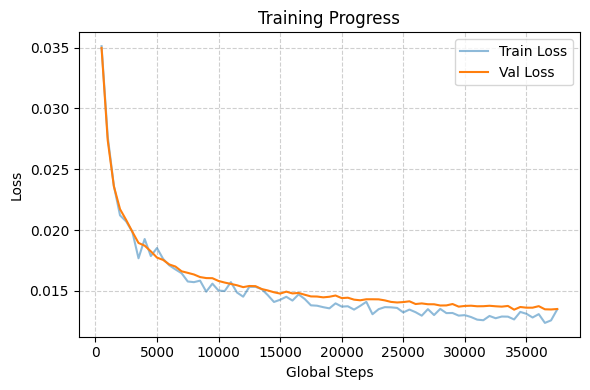

In [ ]:
plot_training_results(train_losses2, val_losses2, 500, title="Training Progress")

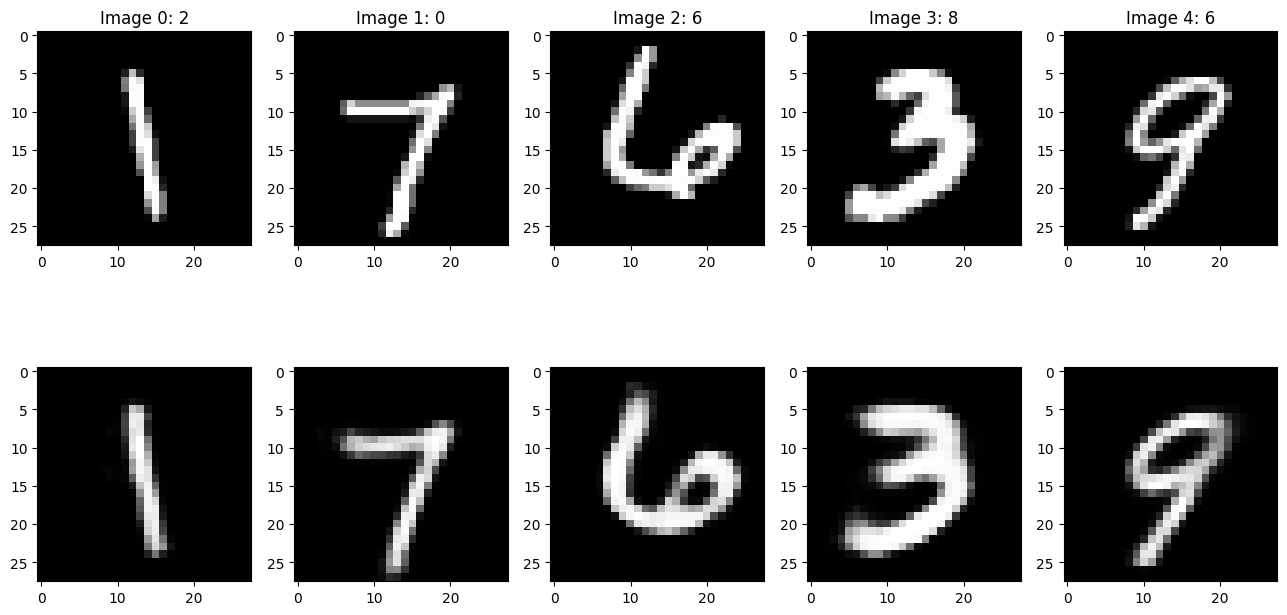

In [ ]:
np.random.seed(123)
random_indices = np.random.choice(len(mnist_test), size=5)

fig, axes = plt.subplots(2, 5, figsize=(16, 8))

model2.eval()
for i, ind in enumerate(random_indices):
  with torch.no_grad():
    input = mnist_test[ind][0].to(device)
    reconst, _ = model2(input.unsqueeze(0))
  axes[0][i].imshow(input.squeeze().cpu().numpy(), cmap="gray")
  axes[1][i].imshow(reconst.squeeze().cpu().numpy(), cmap="gray")
  axes[0][i].set_title(f"Image {i}: {mnist_train[ind][1]}") # it should be Image {ind}


Extracting 10D latents...

Applying t-SNE (this may take a minute)...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 10000 samples in 0.014s...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computed neighbors for 10000 samples in 1.406s...
[t-SNE] Computed conditional probabilities for sample 1000 / 10000
[t-SNE] Computed conditional probabilities for sample 2000 / 10000
[t-SNE] Computed conditional probabilities for sample 3000 / 10000
[t-SNE] Computed conditional probabilities for sample 4000 / 10000
[t-SNE] Computed conditional probabilities for sample 5000 / 10000
[t-SNE] Computed conditional probabilities for sample 6000 / 10000
[t-SNE] Computed conditional probabilities for sample 7000 / 10000
[t-SNE] Computed conditional probabilities for sample 8000 / 10000
[t-SNE] Computed conditional probabilities for sample 9000 / 10000
[t-SNE] Computed conditional probabilities for sample 10000 / 10000
[t-SNE] Mean sigma: 1.960021
[t-SNE] KL divergence after 250 iterations with early exaggeration: 81.288689
[t-SNE] KL divergence after 1000 iterations: 1.714736


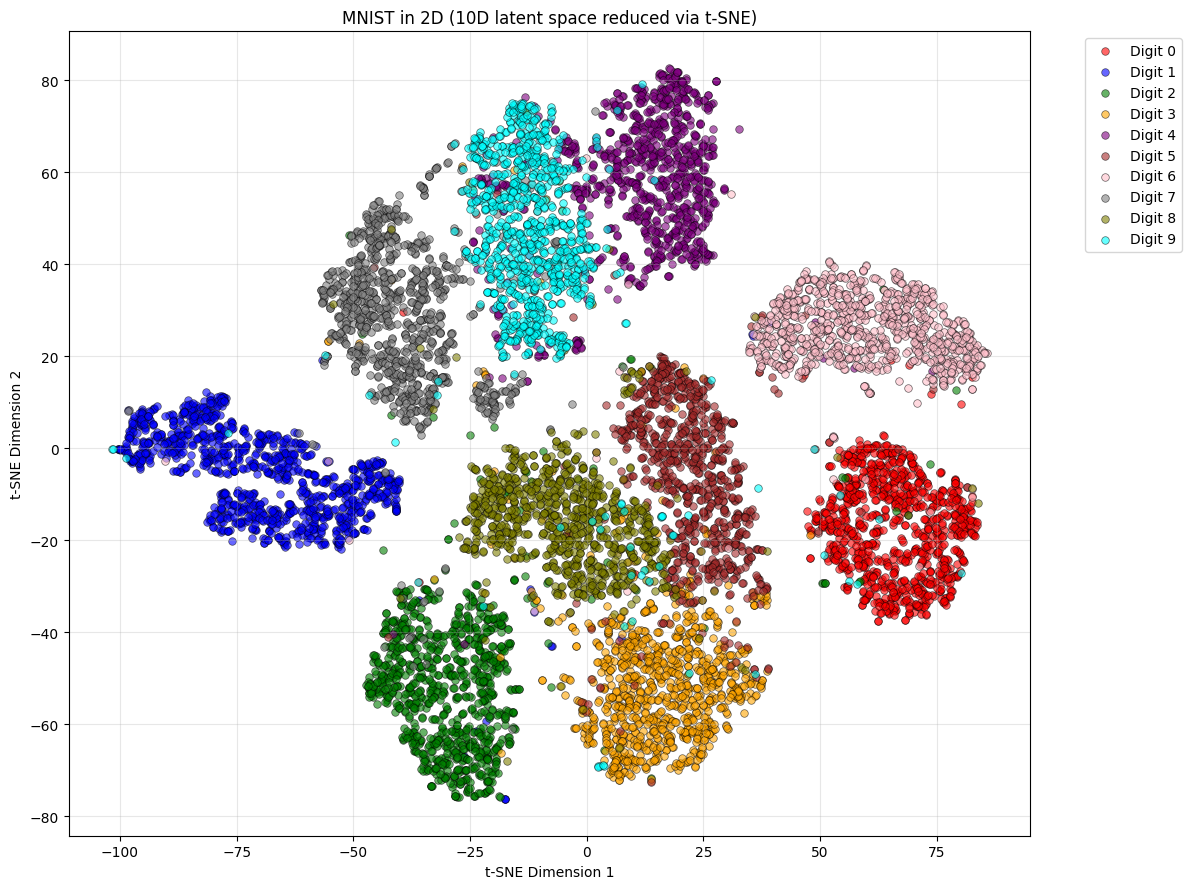


t-SNE visualization complete!
Original latent shape: (10000, 10)
t-SNE reduced shape: (10000, 2)


In [ ]:
print("\nExtracting 10D latents...")
all_latents = []
all_labels = []

model2.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        latents = model2.encoder(images)

        all_latents.append(latents.cpu().numpy())
        all_labels.append(labels.numpy())

latents_10d = np.vstack(all_latents)
labels = np.concatenate(all_labels)

# Apply t-SNE to reduce 10D to 2D
print("\nApplying t-SNE (this may take a minute)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000, verbose=1)
latents_2d = tsne.fit_transform(latents_10d)

# Plot
plt.figure(figsize=(12, 9))

# Define colors for each digit (0-9)
colors = ['red', 'blue', 'green', 'orange', 'purple',
          'brown', 'pink', 'gray', 'olive', 'cyan']

# Plot each digit with its own color
for digit in range(10):
    mask = labels == digit
    plt.scatter(latents_2d[mask, 0], latents_2d[mask, 1],
                c=colors[digit], label=f'Digit {digit}',
                alpha=0.6, s=30, edgecolors='black', linewidth=0.5)

plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.title('MNIST in 2D (10D latent space reduced via t-SNE)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nt-SNE visualization complete!")
print(f"Original latent shape: {latents_10d.shape}")
print(f"t-SNE reduced shape: {latents_2d.shape}")

In [ ]:
for i in range(latents_10d.shape[-1]):
  print(f"Dimension-{i}\t\tMean:{latents_10d[:,i].mean():.3f}\t\tVariance:{latents_10d[:,i].std()**2:.3f}")

Dimension-0		Mean:2.820		Variance:8.025
Dimension-1		Mean:0.212		Variance:11.715
Dimension-2		Mean:1.754		Variance:14.751
Dimension-3		Mean:-2.131		Variance:9.614
Dimension-4		Mean:-1.830		Variance:12.425
Dimension-5		Mean:-0.035		Variance:5.765
Dimension-6		Mean:0.484		Variance:7.329
Dimension-7		Mean:-1.584		Variance:15.913
Dimension-8		Mean:2.212		Variance:7.470
Dimension-9		Mean:-1.666		Variance:7.485


The latents from Autoencoder are not distibuted normally across every dimension.


Applying PCA...


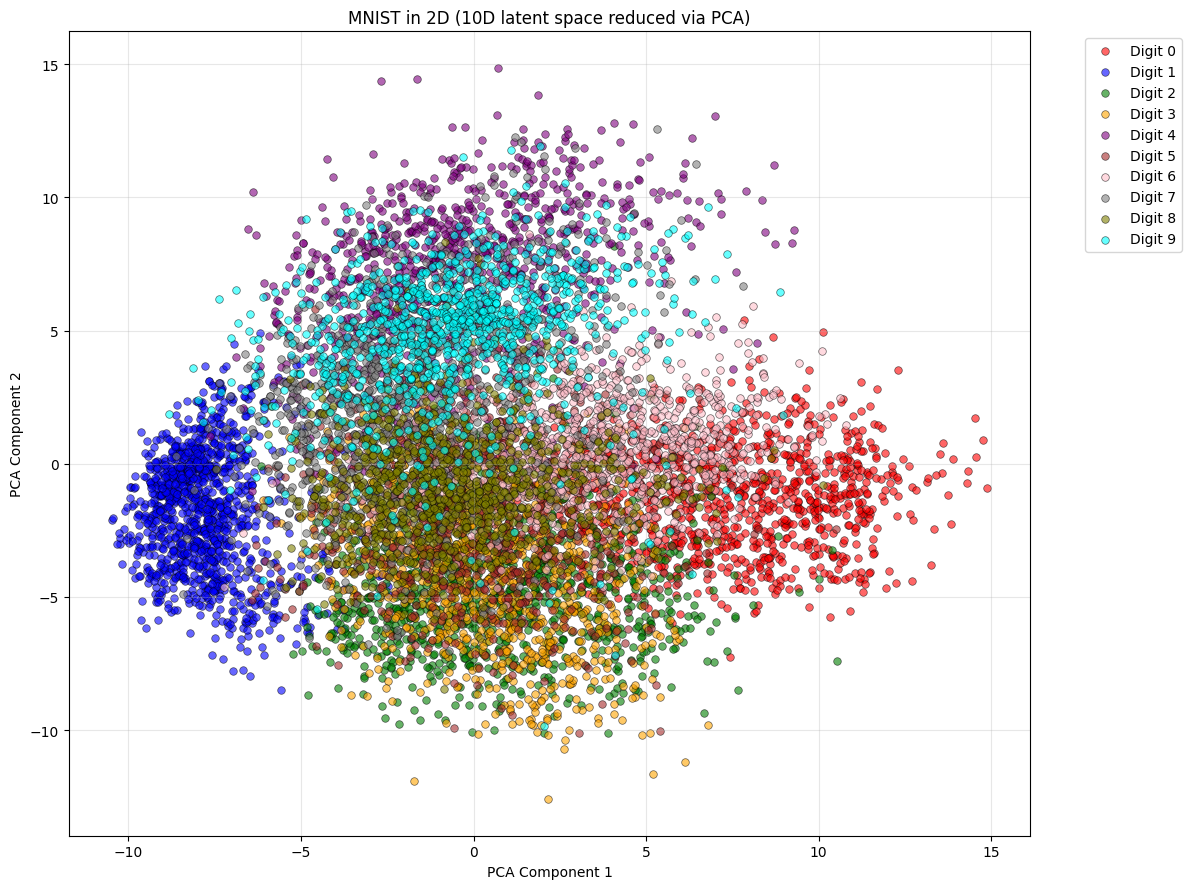


PCA visualization complete!
Original latent shape: (10000, 10)
PCA reduced shape: (10000, 2)


In [ ]:
from sklearn.decomposition import PCA

# Apply PCA to reduce 10D to 2D
print("\nApplying PCA...")
pca = PCA(n_components=2, random_state=42)
latents_2d = pca.fit_transform(latents_10d)

# Plot
plt.figure(figsize=(12, 9))

# Define colors for each digit (0-9)
colors = ['red', 'blue', 'green', 'orange', 'purple',
          'brown', 'pink', 'gray', 'olive', 'cyan']

# Plot each digit with its own color
for digit in range(10):
    mask = labels == digit
    plt.scatter(latents_2d[mask, 0], latents_2d[mask, 1],
                c=colors[digit], label=f'Digit {digit}',
                alpha=0.6, s=30, edgecolors='black', linewidth=0.5)

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('MNIST in 2D (10D latent space reduced via PCA)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nPCA visualization complete!")
print(f"Original latent shape: {latents_10d.shape}")
print(f"PCA reduced shape: {latents_2d.shape}")